# 02 · Modelo supervisado — Forecast de demanda horaria del MEM

**Proyecto:** Forecast de demanda eléctrica del Mercado Eléctrico Mayorista (MEM) argentino.

**Etapa:** Pre-entrega 3 — modelo supervisado de punta a punta: desde la preparación de los datos hasta la evaluación y la selección del modelo, evitando el overfitting con optimización de hiperparámetros.

## Objetivo

Predecir la **demanda eléctrica horaria del MEM (MWh)** a partir de variables de **calendario** y **temperatura**. Se resuelven dos problemas:

1. **Regresión:** cuántos MWh se van a demandar en cada hora.
2. **Clasificación:** si una hora va a ser una **hora pico** (dentro del 10 % de mayor demanda). Es la alerta que le sirve al operador para tener lista la generación de reserva.

## Decisiones de diseño

| Decisión | Elección | Por qué |
|---|---|---|
| Temperatura | Horaria, Open-Meteo, coordenadas de Aeroparque | GBA + Buenos Aires son ~50 % de la demanda. En el EDA la temperatura de Aeroparque explicaba bien la demanda de GBA. |
| Variables | Solo calendario + temperatura, **sin demanda pasada (lags)** | Es el objetivo del proyecto: entender y anticipar la demanda por calendario y clima. Con lags el error baja, pero el modelo se apoya en "lo que pasó ayer" y deja de contar esa historia. |
| Split | Train 2021–2024, test ene-2025 → jul-2026 | Siempre por tiempo: se entrena con el pasado y se evalúa con el futuro. El test tiene un año completo, con verano e invierno. |
| Métrica principal | MAPE | Error porcentual, estándar en la industria eléctrica y fácil de comunicar. |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report, f1_score,
    mean_absolute_error, mean_absolute_percentage_error, precision_score, recall_score,
    roc_auc_score, root_mean_squared_error,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_score, validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = BASE / "data" / "processed"
FIG = BASE / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# semilla fija para que los resultados sean reproducibles
SEMILLA = 42


def guardar(nombre):
    """Muestra el gráfico actual y lo guarda en reports/figures."""
    plt.tight_layout()
    plt.savefig(FIG / f"02_{nombre}.png", bbox_inches="tight")
    plt.show()

## 1. Carga y unión de los datos

- `demanda_horaria_mem.csv`: serie horaria del MEM construida y validada en la pre-entrega 2 (48.912 horas, sin huecos).
- `temperatura_horaria_ba.csv`: temperatura horaria de Buenos Aires, descargada de Open-Meteo con `src/descargar_temperatura.py`.

In [2]:
demanda = pd.read_csv(DATA / "demanda_horaria_mem.csv", parse_dates=["timestamp"])
temperatura = pd.read_csv(DATA / "temperatura_horaria_ba.csv", parse_dates=["timestamp"])

# validate="one_to_one" hace fallar el merge si algún timestamp estuviera repetido en alguna de las dos tablas
df = demanda.merge(temperatura, on="timestamp", how="left", validate="one_to_one")

print(f"Filas: {len(df):,} | {df.timestamp.min()} -> {df.timestamp.max()}")
print(f"Horas sin temperatura: {df.temperatura_c.isna().sum()}")
df[["timestamp", "demanda_mwh", "tipo_dia", "temperatura_c"]].head()

Filas: 48,912 | 2021-01-01 00:00:00 -> 2026-07-31 23:00:00
Horas sin temperatura: 0


,timestamp,demanda_mwh,tipo_dia,temperatura_c
0,2021-01-01 00:00:00,12329.594,no_habil,21.8
1,2021-01-01 01:00:00,12097.918,no_habil,21.6
2,2021-01-01 02:00:00,11805.739,no_habil,21.4
3,2021-01-01 03:00:00,11447.416,no_habil,20.9
4,2021-01-01 04:00:00,11143.879,no_habil,20.4


## 2. Exploración orientada al modelo

En el EDA vimos la relación demanda–temperatura con datos **diarios**. Ahora la miramos con la temperatura **horaria** y elegimos cómo convertirla en variables útiles para el modelo.

Para no tomar decisiones mirando el período de test, esta exploración se hace **solo con los datos de entrenamiento** (hasta 2024).

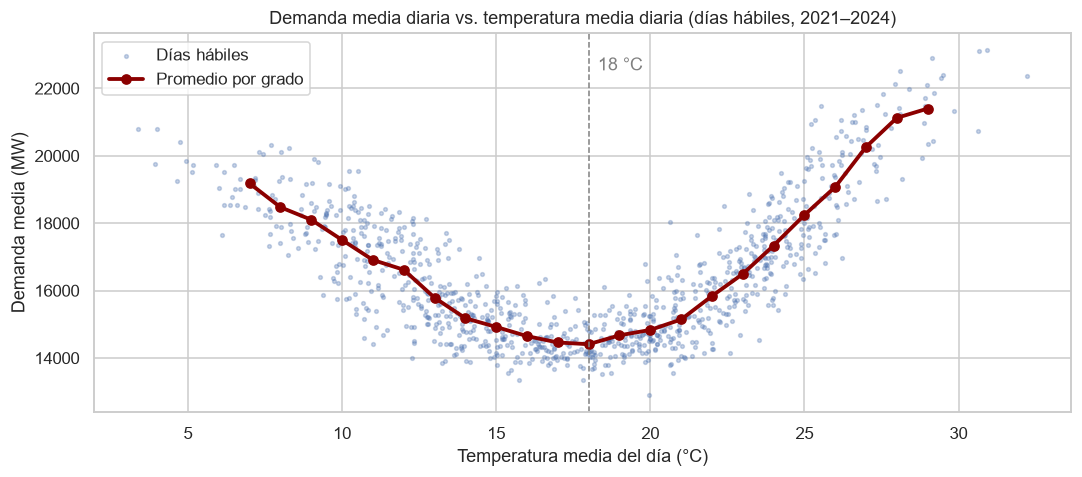

Temperatura con menor demanda promedio: 18.0 °C


In [3]:
FIN_TRAIN = pd.Timestamp("2025-01-01")
en_train = df["timestamp"] < FIN_TRAIN

# demanda media diaria vs temperatura media diaria, en días hábiles del período de entrenamiento
diario = (
    df[en_train]
    .groupby(df.timestamp.dt.normalize())
    .agg(demanda=("demanda_mwh", "mean"), temperatura=("temperatura_c", "mean"), tipo_dia=("tipo_dia", "first"))
)
habiles = diario[diario.tipo_dia == "habil"]
por_grado = habiles.groupby(habiles.temperatura.round())["demanda"].agg(["mean", "count"])
por_grado = por_grado[por_grado["count"] >= 10]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(habiles.temperatura, habiles.demanda, s=6, alpha=0.3, label="Días hábiles")
ax.plot(por_grado.index, por_grado["mean"], color="darkred", lw=2.5, marker="o", label="Promedio por grado")
ax.axvline(18, color="gray", ls="--", lw=1)
ax.text(18.3, ax.get_ylim()[1] * 0.97, "18 °C", color="gray", va="top")
ax.set(title="Demanda media diaria vs. temperatura media diaria (días hábiles, 2021–2024)",
       xlabel="Temperatura media del día (°C)", ylabel="Demanda media (MW)")
ax.legend()
guardar("demanda_vs_temperatura_train")

print("Temperatura con menor demanda promedio:", por_grado["mean"].idxmin(), "°C")

La U se confirma con la temperatura horaria de Open-Meteo: la demanda es mínima alrededor de los **18 °C** y sube hacia los dos lados. Esa temperatura es la "zona de confort": no se prende ni la calefacción ni el aire acondicionado.

Eso define cómo transformar la temperatura. Una regresión lineal con la temperatura "cruda" ajustaría una recta, y una recta no puede bajar y después subir. Por eso se usan los **grados-día**, una convención de la industria energética:

- **Grados de calefacción (`hdd`):** cuántos grados por debajo de 18 °C está la temperatura. Vale 0 si hace más de 18 °C.
- **Grados de refrigeración (`cdd`):** cuántos grados por encima de 18 °C. Vale 0 si hace menos.

Así cada rama de la U se vuelve una relación lineal que hasta la regresión lineal puede aprender.

## 3. Feature engineering

| Variable | Qué es | Por qué |
|---|---|---|
| `hora` | Hora del día (0–23) | La curva de carga diaria: valle de madrugada, picos de tarde o noche. |
| `dia_semana` | 0 = lunes … 6 = domingo | El perfil semanal visto en el EDA. |
| `mes` | 1–12 | La estacionalidad anual y la hora del pico, que cambia según la estación. |
| `es_habil` | 1 si CAMMESA clasifica el día como hábil | Captura **feriados**, que el día de la semana solo no ve. |
| `temperatura_c` | Temperatura de esa hora | El efecto inmediato del clima. |
| `temp_24h` | Promedio de las últimas 24 h | **Inercia térmica**: los edificios tardan en calentarse o enfriarse, así que la demanda responde al calor o frío acumulado, no solo al de esa hora. |
| `hdd`, `cdd` | Grados de calefacción y refrigeración sobre `temp_24h`, base 18 °C | Las dos ramas de la U, como se explicó arriba. |

Todas las variables se pueden conocer **antes** de la hora a predecir: el calendario se sabe de antemano y la temperatura sale del pronóstico del tiempo. Ninguna usa la demanda.

In [4]:
TEMP_CONFORT = 18

df["hora"] = df.timestamp.dt.hour
df["dia_semana"] = df.timestamp.dt.dayofweek
df["mes"] = df.timestamp.dt.month
df["es_habil"] = (df["tipo_dia"] == "habil").astype(int)

# promedio móvil de las últimas 24 horas (incluida la actual); las primeras horas de la serie usan las que haya
df["temp_24h"] = df["temperatura_c"].rolling(24, min_periods=1).mean()
df["hdd"] = (TEMP_CONFORT - df["temp_24h"]).clip(lower=0)
df["cdd"] = (df["temp_24h"] - TEMP_CONFORT).clip(lower=0)

CATEGORICAS = ["hora", "dia_semana", "mes"]
NUMERICAS = ["es_habil", "temperatura_c", "temp_24h", "hdd", "cdd"]
VARIABLES = CATEGORICAS + NUMERICAS

df[["timestamp"] + VARIABLES + ["demanda_mwh"]].head()

,timestamp,hora,dia_semana,mes,es_habil,temperatura_c,temp_24h,hdd,cdd,demanda_mwh
0,2021-01-01 00:00:00,0,4,1,0,21.8,21.800,0.0,3.800,12329.594
1,2021-01-01 01:00:00,1,4,1,0,21.6,21.700,0.0,3.700,12097.918
2,2021-01-01 02:00:00,2,4,1,0,21.4,21.600,0.0,3.600,11805.739
3,2021-01-01 03:00:00,3,4,1,0,20.9,21.425,0.0,3.425,11447.416
4,2021-01-01 04:00:00,4,4,1,0,20.4,21.220,0.0,3.220,11143.879


In [5]:
# correlación de cada variable numérica con la demanda (solo train)
df.loc[en_train, NUMERICAS + ["demanda_mwh"]].corr()["demanda_mwh"].drop("demanda_mwh").round(2).sort_values()

temp_24h         0.10
hdd              0.18
temperatura_c    0.22
es_habil         0.31
cdd              0.38
Name: demanda_mwh, dtype: float64

La correlación lineal es una medida limitada para una relación en U, pero sirve para comparar:

- `cdd` (0,38) correlaciona más que la temperatura cruda (0,22): al separar el calor del frío, la rama de verano se vuelve una relación lineal.
- `hdd` correlaciona menos (0,18) porque el frío mueve menos la demanda que el calor. En el gráfico anterior, de 18 °C a 28 °C la demanda sube unos 6.700 MW (~670 MW por grado), y de 18 °C a 7 °C sube unos 4.800 MW (~430 MW por grado).

La prueba de fuego de estas variables no es la correlación, sino si mejoran el modelo.

## 4. Separación temporal en entrenamiento y test

En series temporales **no se puede separar al azar**. Si una hora de marzo de 2025 quedara en train y la siguiente en test, el modelo "conocería el futuro" y el error de test sería engañosamente bajo. Se entrena con el pasado y se evalúa con el futuro, igual que pasaría en la operación real.

In [6]:
X = df[VARIABLES]
y = df["demanda_mwh"]
X_train, X_test = X[en_train], X[~en_train]
y_train, y_test = y[en_train], y[~en_train]
t_test = df.loc[~en_train, "timestamp"]

print(f"Train: {len(X_train):,} horas ({df.timestamp[en_train].min().date()} -> {df.timestamp[en_train].max().date()})")
print(f"Test:  {len(X_test):,} horas ({t_test.min().date()} -> {t_test.max().date()})")
print(f"Proporción de test: {len(X_test) / len(X):.0%}")

Train: 35,064 horas (2021-01-01 -> 2024-12-31)
Test:  13,848 horas (2025-01-01 -> 2026-07-31)
Proporción de test: 28%


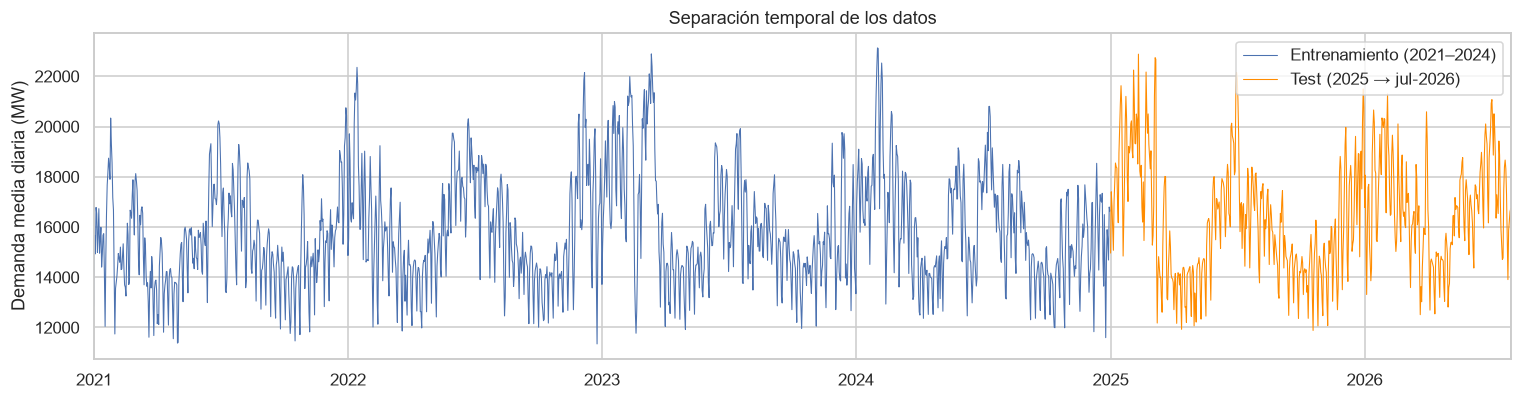

In [7]:
fig, ax = plt.subplots(figsize=(14, 3.8))
serie = df.set_index("timestamp")["demanda_mwh"].resample("D").mean()
serie[serie.index < FIN_TRAIN].plot(ax=ax, lw=0.7, label="Entrenamiento (2021–2024)")
serie[serie.index >= FIN_TRAIN].plot(ax=ax, lw=0.7, color="darkorange", label="Test (2025 → jul-2026)")
ax.set(title="Separación temporal de los datos", ylabel="Demanda media diaria (MW)", xlabel="")
ax.legend()
guardar("split_temporal")

### Validación cruzada temporal

Para elegir hiperparámetros sin tocar el test se usa **validación cruzada temporal** (`TimeSeriesSplit`) dentro del período de entrenamiento: se entrena con un bloque inicial y se valida con el bloque siguiente, y el bloque de entrenamiento va creciendo en cada vuelta. Así la validación respeta el orden del tiempo igual que el split final.

El **test se usa una sola vez**, al final, para medir los modelos ya elegidos.

In [8]:
cv_temporal = TimeSeriesSplit(n_splits=5)

for i, (idx_tr, idx_val) in enumerate(cv_temporal.split(X_train), start=1):
    t = df.loc[en_train, "timestamp"]
    print(f"Fold {i}: entrena {t.iloc[idx_tr[0]].date()} -> {t.iloc[idx_tr[-1]].date()} | "
          f"valida {t.iloc[idx_val[0]].date()} -> {t.iloc[idx_val[-1]].date()}")

Fold 1: entrena 2021-01-01 -> 2021-09-01 | valida 2021-09-01 -> 2022-05-02
Fold 2: entrena 2021-01-01 -> 2022-05-02 | valida 2022-05-03 -> 2023-01-01
Fold 3: entrena 2021-01-01 -> 2023-01-01 | valida 2023-01-01 -> 2023-09-01
Fold 4: entrena 2021-01-01 -> 2023-09-01 | valida 2023-09-02 -> 2024-05-02
Fold 5: entrena 2021-01-01 -> 2024-05-02 | valida 2024-05-02 -> 2024-12-31


## 5. Métricas

- **MAPE** (error porcentual absoluto medio): en promedio, en qué porcentaje se equivoca el modelo. Es la métrica principal: es la que usa la industria y se entiende sin conocer la escala ("se equivoca un 4 %").
- **RMSE** (raíz del error cuadrático medio, en MWh): penaliza más los errores grandes. Importa porque un error grande en una hora pico es el más caro para el operador.
- **MAE** (error absoluto medio, en MWh): el error típico en unidades físicas.

MAPE no tiene el problema de dividir por cero, porque la demanda nunca baja de ~9.000 MW.

In [9]:
def evaluar(nombre, y_real, y_pred):
    """Devuelve las métricas de regresión de un modelo como diccionario."""
    return {
        "modelo": nombre,
        "MAPE_%": round(mean_absolute_percentage_error(y_real, y_pred) * 100, 2),
        "RMSE_MWh": round(root_mean_squared_error(y_real, y_pred)),
        "MAE_MWh": round(mean_absolute_error(y_real, y_pred)),
        "sesgo_MWh": round((y_real - y_pred).mean()),  # > 0: el modelo subestima en promedio
    }

## 6. Referencia ingenua

Antes de cualquier modelo hace falta un piso: si un modelo de machine learning no le gana a una regla simple, no aporta nada.

La regla: **predecir el promedio histórico de esa hora, en ese mes y en ese tipo de día** (hábil o no). Es lo que haría alguien con una planilla de cálculo.

In [10]:
perfil = df[en_train].groupby(["mes", "hora", "es_habil"])["demanda_mwh"].mean().rename("pred")
pred_ingenua = df.loc[~en_train].join(perfil, on=["mes", "hora", "es_habil"])["pred"]

resultados = [evaluar("Referencia ingenua (perfil promedio)", y_test, pred_ingenua)]
pd.DataFrame(resultados)

,modelo,MAPE_%,RMSE_MWh,MAE_MWh,sesgo_MWh
0,Referencia ingenua (perfil promedio),7.59,1727,1286,419


## 7. Baseline: Regresión Lineal

La regresión lineal es el modelo más simple e interpretable. Para que funcione hay que preparar las variables:

- `hora`, `dia_semana` y `mes` se pasan con **one-hot encoding** (una columna 0/1 por cada valor). Si se pasara `hora` como número, el modelo asumiría que la demanda sube o baja en línea recta de la hora 0 a la 23, y la curva diaria no es así.
- Las variables de temperatura entran como números. Gracias a `hdd` y `cdd`, la U ya está "linealizada".

El preprocesamiento va dentro de un **pipeline**, así se ajusta solo con los datos de entrenamiento de cada fold y no se filtra información del test.

In [11]:
preprocesamiento_lineal = ColumnTransformer(
    [("one_hot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS)],
    remainder="passthrough",
)
modelo_lineal = make_pipeline(preprocesamiento_lineal, LinearRegression())

# MAPE en validación cruzada temporal (scikit-learn devuelve el error con signo negativo)
cv_lineal = -cross_val_score(modelo_lineal, X_train, y_train, cv=cv_temporal, scoring="neg_mean_absolute_percentage_error")
print(f"Regresión lineal | MAPE validación cruzada: {cv_lineal.mean() * 100:.2f} % (± {cv_lineal.std() * 100:.2f})")

modelo_lineal.fit(X_train, y_train)

Regresión lineal | MAPE validación cruzada: 6.33 % (± 0.17)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['hora','dia_semana','mes',...,'temp_24h','hdd','cdd']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

## 8. Modelo principal: Random Forest

Un Random Forest promedia muchos árboles de decisión, cada uno entrenado con una muestra distinta de los datos. Tiene tres ventajas para este problema:

- Captura **no linealidades e interacciones** sin que haya que construirlas a mano. Por ejemplo, que el pico de la tarde depende del mes, que es la interacción hora × estación del EDA.
- Es robusto a outliers.
- Permite medir la importancia de cada variable.

A los árboles no les hace falta one-hot: pueden cortar `hora` en cualquier punto ("hora ≤ 6") y aprender la curva por tramos.

### 8.1 Overfitting: la profundidad de los árboles

Un árbol sin límite de profundidad puede memorizar el entrenamiento: error casi cero en train y mucho peor en datos nuevos. La **curva de validación** muestra el error en train y en validación al variar `max_depth`.

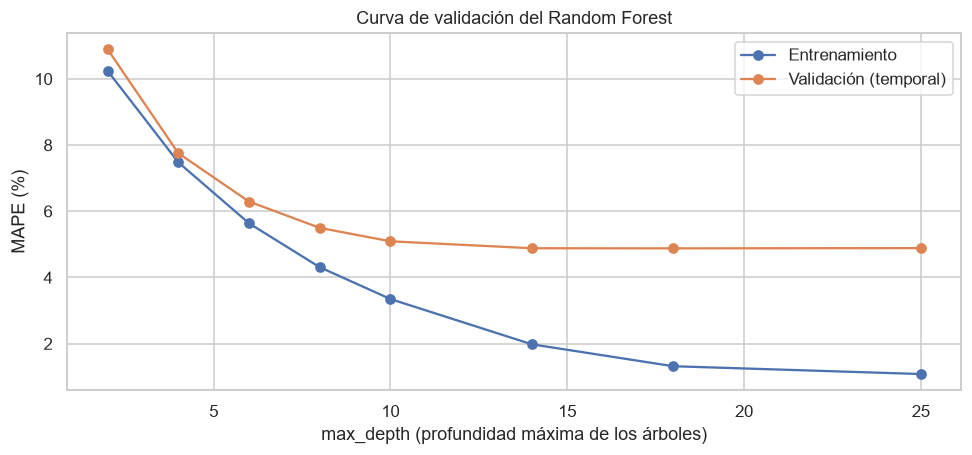

,max_depth,MAPE_train_%,MAPE_validacion_%
0,2,10.24,10.89
1,4,7.48,7.75
2,6,5.63,6.29
3,8,4.31,5.50
4,10,3.35,5.09
5,14,1.98,4.88
6,18,1.32,4.88
7,25,1.08,4.89


In [12]:
profundidades = [2, 4, 6, 8, 10, 14, 18, 25]
mape_train, mape_val = validation_curve(
    RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEMILLA),
    X_train, y_train,
    param_name="max_depth", param_range=profundidades,
    cv=cv_temporal, scoring="neg_mean_absolute_percentage_error", n_jobs=1,
)
curva = pd.DataFrame({
    "max_depth": profundidades,
    "MAPE_train_%": -mape_train.mean(axis=1) * 100,
    "MAPE_validacion_%": -mape_val.mean(axis=1) * 100,
})

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(curva.max_depth, curva["MAPE_train_%"], marker="o", label="Entrenamiento")
ax.plot(curva.max_depth, curva["MAPE_validacion_%"], marker="o", label="Validación (temporal)")
ax.set(title="Curva de validación del Random Forest", xlabel="max_depth (profundidad máxima de los árboles)", ylabel="MAPE (%)")
ax.legend()
guardar("curva_validacion_rf")
curva.round(2)

Lectura de la curva:

- Con árboles muy poco profundos (2–4) el modelo es demasiado simple y se equivoca tanto en train como en validación: **underfitting**.
- Al aumentar la profundidad, el error de entrenamiento sigue bajando, pero el de validación deja de mejorar. La distancia creciente entre las dos curvas es el **overfitting**: el modelo aprende detalles del entrenamiento que no se repiten en el futuro.

La profundidad conveniente es la que minimiza el error de **validación**, no el de entrenamiento.

### 8.2 Optimización de hiperparámetros

Se buscan varios hiperparámetros a la vez con `RandomizedSearchCV`: prueba combinaciones al azar dentro de un rango y se queda con la de menor error en la validación cruzada temporal. Es más eficiente que probar todas las combinaciones (`GridSearchCV`).

- `max_depth`: profundidad máxima de cada árbol.
- `min_samples_leaf`: mínimo de horas en cada hoja. Valores más altos obligan al árbol a generalizar.
- `max_features`: cuántas variables considera cada corte. Usar menos variables hace que los árboles sean más distintos entre sí y el promedio, más robusto.

In [13]:
busqueda_rf = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEMILLA),
    param_distributions={
        "max_depth": [8, 10, 12, 14, 16, 20, None],
        "min_samples_leaf": [1, 3, 5, 10, 20, 40],
        "max_features": [0.5, 0.7, 1.0],
    },
    n_iter=20, cv=cv_temporal, scoring="neg_mean_absolute_percentage_error",
    random_state=SEMILLA, n_jobs=1,
)
busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print(f"MAPE validación cruzada: {-busqueda_rf.best_score_ * 100:.2f} %")

Mejores hiperparámetros: {'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': None}
MAPE validación cruzada: 4.79 %


## 9. Comparación: Gradient Boosting

Como comparación se entrena un **Gradient Boosting** (`HistGradientBoostingRegressor`). A diferencia del Random Forest, que promedia árboles independientes, el boosting construye los árboles **en secuencia**: cada uno corrige los errores de los anteriores. Suele ser más preciso, pero tiene más hiperparámetros sensibles al overfitting, como la tasa de aprendizaje y la cantidad de iteraciones.

In [14]:
busqueda_gb = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=SEMILLA),
    param_distributions={
        "learning_rate": [0.02, 0.05, 0.1],
        "max_iter": [200, 400, 800],
        "max_depth": [None, 6, 10],
        "min_samples_leaf": [20, 50, 100],
        "l2_regularization": [0.0, 0.1, 1.0],
    },
    n_iter=20, cv=cv_temporal, scoring="neg_mean_absolute_percentage_error",
    random_state=SEMILLA, n_jobs=1,
)
busqueda_gb.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_gb.best_params_)
print(f"MAPE validación cruzada: {-busqueda_gb.best_score_ * 100:.2f} %")

Mejores hiperparámetros: {'min_samples_leaf': 50, 'max_iter': 200, 'max_depth': 10, 'learning_rate': 0.05, 'l2_regularization': 0.1}
MAPE validación cruzada: 4.54 %


## 10. Selección del modelo

El modelo se elige con el error de **validación cruzada**, no con el de test. Si se eligiera mirando el test, el test dejaría de ser una medición imparcial del desempeño futuro.

In [15]:
seleccion = pd.DataFrame({
    "modelo": ["Regresión lineal", "Random Forest", "Gradient Boosting"],
    "MAPE_validacion_%": [cv_lineal.mean() * 100, -busqueda_rf.best_score_ * 100, -busqueda_gb.best_score_ * 100],
}).round(2).sort_values("MAPE_validacion_%")
seleccion

,modelo,MAPE_validacion_%
2,Gradient Boosting,4.54
1,Random Forest,4.79
0,Regresión lineal,6.33


## 11. Evaluación final en test (2025 → jul-2026)

Ahora sí se miden todos los modelos en el período de test, que ninguno vio durante el entrenamiento ni la selección.

In [16]:
modelo_rf = busqueda_rf.best_estimator_
modelo_gb = busqueda_gb.best_estimator_

predicciones = {
    "Regresión lineal": modelo_lineal.predict(X_test),
    "Random Forest": modelo_rf.predict(X_test),
    "Gradient Boosting": modelo_gb.predict(X_test),
}
for nombre, pred in predicciones.items():
    resultados.append(evaluar(nombre, y_test, pred))

tabla_test = pd.DataFrame(resultados).set_index("modelo")
tabla_test

,MAPE_%,RMSE_MWh,MAE_MWh,sesgo_MWh
modelo,,,,
Referencia ingenua (perfil promedio),7.59,1727,1286,419
Regresión lineal,6.01,1301,996,289
Random Forest,4.17,959,705,273
Gradient Boosting,3.97,918,671,270


In [17]:
# error de entrenamiento vs test de cada modelo: una diferencia grande indicaría overfitting
modelos = {"Regresión lineal": modelo_lineal, "Random Forest": modelo_rf, "Gradient Boosting": modelo_gb}
pd.DataFrame({
    "MAPE_train_%": {n: mean_absolute_percentage_error(y_train, m.predict(X_train)) * 100 for n, m in modelos.items()},
    "MAPE_test_%": {n: mean_absolute_percentage_error(y_test, p) * 100 for n, p in predicciones.items()},
}).round(2)

,MAPE_train_%,MAPE_test_%
Regresión lineal,6.12,6.01
Random Forest,2.57,4.17
Gradient Boosting,3.41,3.97


### 11.1 Predicción vs. realidad

Dos semanas del test, una de verano y una de invierno, con el mejor modelo de validación.

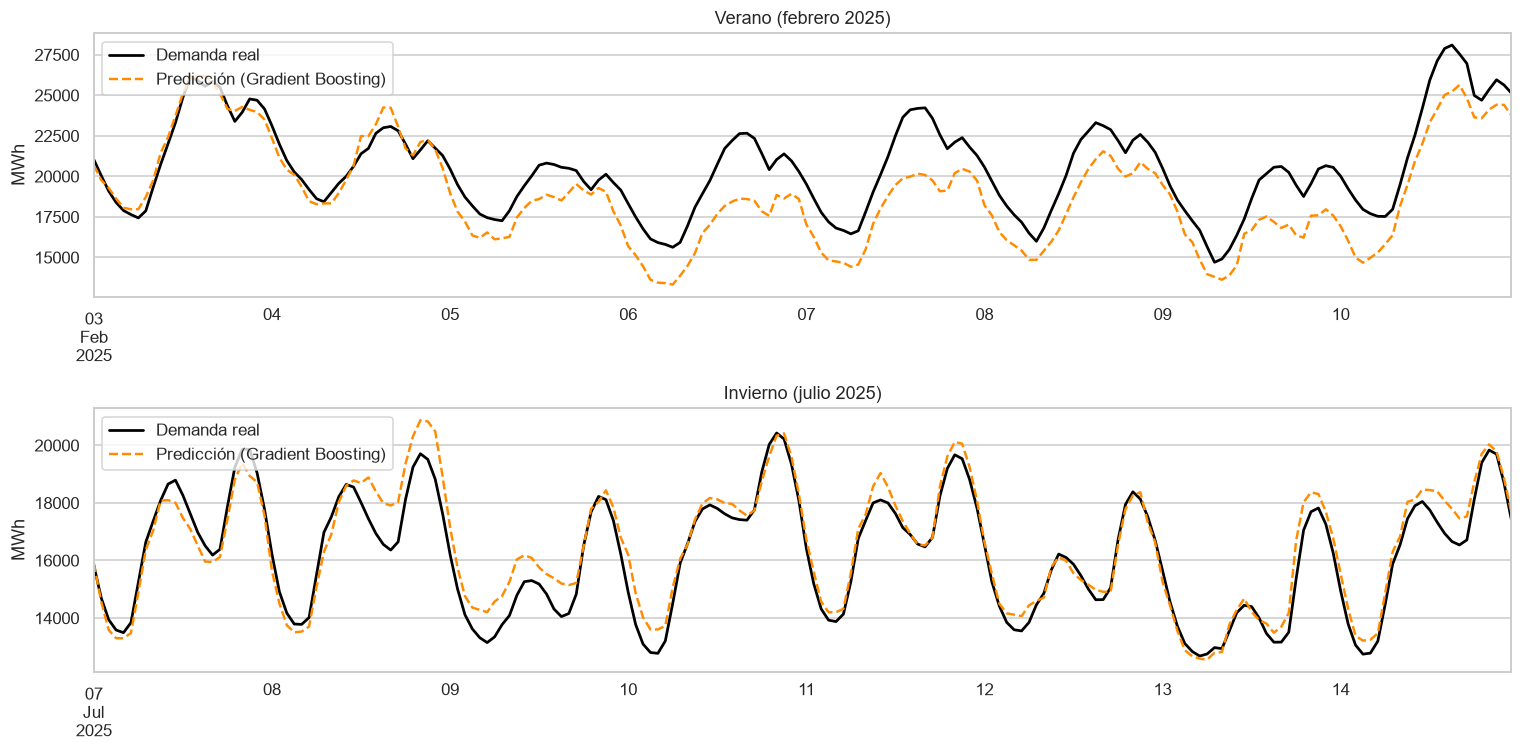

In [18]:
MEJOR = seleccion.iloc[0]["modelo"]
pred_mejor = pd.Series(predicciones[MEJOR], index=t_test.values)
real = pd.Series(y_test.values, index=t_test.values)

semanas = {"Verano (febrero 2025)": ("2025-02-03", "2025-02-10"), "Invierno (julio 2025)": ("2025-07-07", "2025-07-14")}
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, (titulo, (desde, hasta)) in zip(axes, semanas.items()):
    real[desde:hasta].plot(ax=ax, lw=1.8, color="black", label="Demanda real")
    pred_mejor[desde:hasta].plot(ax=ax, lw=1.6, color="darkorange", ls="--", label=f"Predicción ({MEJOR})")
    ax.set(title=titulo, ylabel="MWh", xlabel="")
    ax.legend(loc="upper left")
guardar("prediccion_vs_real")

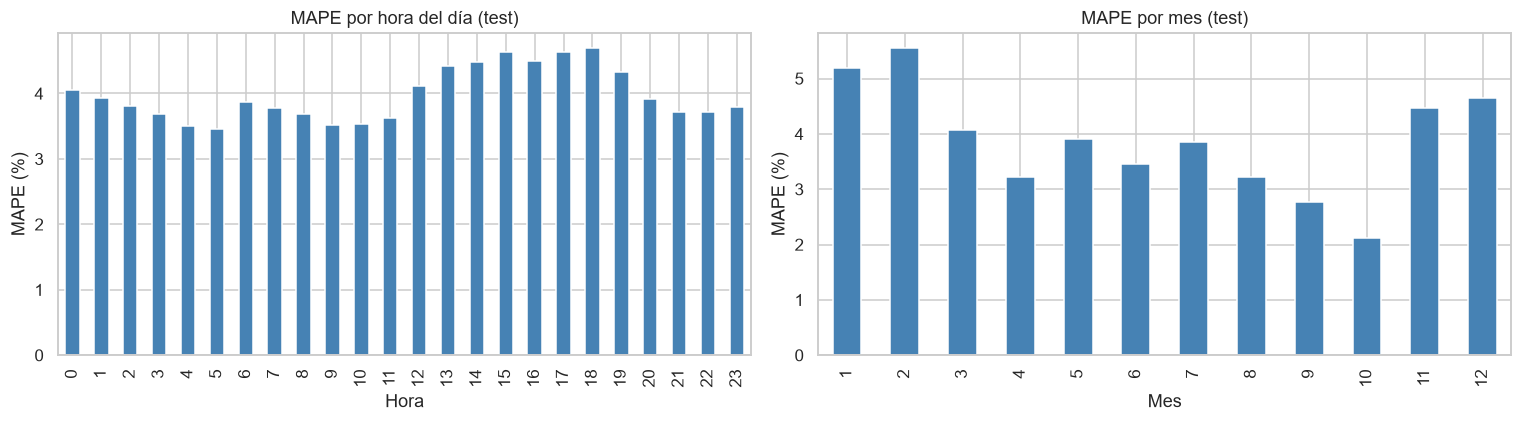

In [19]:
# MAPE del mejor modelo según la hora del día y el mes
error_pct = (real - pred_mejor).abs() / real * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
error_pct.groupby(error_pct.index.hour).mean().plot.bar(ax=axes[0], color="steelblue")
axes[0].set(title="MAPE por hora del día (test)", xlabel="Hora", ylabel="MAPE (%)")
error_pct.groupby(error_pct.index.month).mean().plot.bar(ax=axes[1], color="steelblue")
axes[1].set(title="MAPE por mes (test)", xlabel="Mes", ylabel="MAPE (%)")
guardar("error_por_hora_y_mes")

In [20]:
# error medio (real - predicción) por año: si es siempre positivo, el modelo subestima
sesgo = (real - pred_mejor)
pd.DataFrame({
    "sesgo_MWh": sesgo.groupby(sesgo.index.year).mean().round(0),
    "sesgo_%": (sesgo / real * 100).groupby(sesgo.index.year).mean().round(2),
})

,sesgo_MWh,sesgo_%
2025,159.0,0.72
2026,460.0,2.64


**El modelo subestima, y cada vez más:** 0,7 % en 2025 y 2,6 % en 2026. Es la **tendencia de crecimiento** de la demanda que vimos en el EDA (+4 % en 2026). El modelo solo conoce calendario y temperatura, así que aprende el nivel de 2021–2024 y no puede saber que la demanda de base creció. Además, los modelos de árboles no pueden extrapolar: nunca predicen valores más altos que los que vieron en entrenamiento.

También se ve en la semana de verano: el 10 de febrero de 2025 (récord histórico de la serie, 28.094 MW) el modelo se queda unos 2.500 MW corto. Fue una ola de calor nacional, y una sola temperatura de Buenos Aires no la refleja completa. Por eso el error es mayor en **enero–febrero** y en las **horas de la tarde (13–18 h)**: son las horas de pico de verano, las más difíciles y las más importantes para el operador.

### 11.2 ¿Qué variables usa el modelo?

La **importancia por permutación** mide cuánto empeora el error cuando se "desordenan" al azar los valores de una variable en el test. Si el error sube mucho, el modelo depende de esa variable. Tiene una ventaja sobre la importancia interna de los árboles: se mide sobre datos que el modelo no vio.

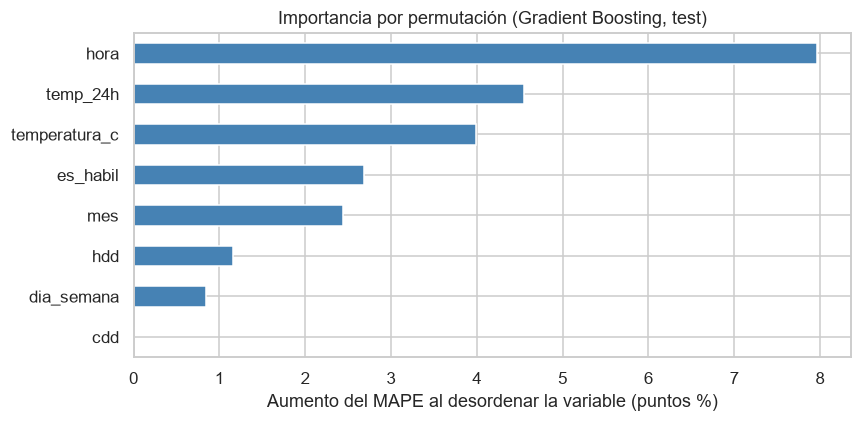

hora             7.97
temp_24h         4.56
temperatura_c    3.99
es_habil         2.68
mes              2.44
hdd              1.16
dia_semana       0.84
cdd              0.00
dtype: float64

In [21]:
importancia = permutation_importance(
    modelos[MEJOR], X_test, y_test, n_repeats=5, random_state=SEMILLA,
    scoring="neg_mean_absolute_percentage_error",
)
# aumento del MAPE (en puntos porcentuales) al desordenar cada variable
imp = pd.Series(importancia.importances_mean * 100, index=VARIABLES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color="steelblue")
ax.set(title=f"Importancia por permutación ({MEJOR}, test)", xlabel="Aumento del MAPE al desordenar la variable (puntos %)")
guardar("importancia_variables")
imp.sort_values(ascending=False).round(2)

- **`hora` es la variable más importante:** la curva diaria explica la mayor parte de la variación de la demanda.
- Le siguen las de **temperatura** (`temp_24h` y `temperatura_c`) y el **calendario** (`es_habil`, `mes`).
- `cdd` aparece con importancia ~0 y `hdd` baja. No significa que el calor no importe: llevan la misma información que `temp_24h`, de la que se calculan. Cuando se desordena `cdd`, el modelo sigue teniendo la temperatura en `temp_24h`. Es una limitación conocida de la importancia por permutación con variables correlacionadas: reparte (o esconde) la importancia entre ellas.

## 12. Clasificación: ¿va a ser una hora pico?

Además de los MWh, al operador le sirve una **alerta**: saber de antemano qué horas van a estar entre las de mayor demanda, para tener lista la generación de reserva.

**Variable objetivo:** `es_pico` = 1 si la demanda de la hora supera el **percentil 90 del período de entrenamiento**. El umbral se calcula solo con train: si se calculara con todo el dataset, el modelo estaría usando información del test.

In [22]:
UMBRAL_PICO = y_train.quantile(0.90)
pico_train = (y_train >= UMBRAL_PICO).astype(int)
pico_test = (y_test >= UMBRAL_PICO).astype(int)

print(f"Umbral de hora pico: {UMBRAL_PICO:,.0f} MWh")
print(f"Horas pico en train: {pico_train.mean():.1%} | en test: {pico_test.mean():.1%}")

Umbral de hora pico: 19,579 MWh
Horas pico en train: 10.0% | en test: 14.9%


Las clases están **desbalanceadas**: solo 1 de cada 10 horas es pico. Esto cambia cómo evaluar:

- La **exactitud** (accuracy) engaña: un modelo que diga siempre "no es pico" acierta el 90 % en train y no sirve para nada.
- Importan la **precisión** (de las alertas que da el modelo, cuántas son picos reales) y sobre todo el **recall** (de los picos reales, cuántos anticipa). Para el operador, un pico no anticipado es más caro que una falsa alarma.
- El **F1** resume precisión y recall en un número, y el **AUC-PR** mide qué tan bien ordena el modelo las horas de más a menos riesgosas.

Por eso los dos modelos se entrenan con `class_weight="balanced"`, que les da más peso a los ejemplos de la clase minoritaria.

### 12.1 Baseline: Regresión Logística

La versión de clasificación de la regresión lineal. Además del one-hot, las variables numéricas se **estandarizan** (media 0, desvío 1), porque la regularización de la regresión logística penaliza más a las variables con números grandes.

In [23]:
preprocesamiento_logistica = ColumnTransformer([
    ("one_hot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
    ("escalado", StandardScaler(), NUMERICAS),
])
modelo_logistica = make_pipeline(
    preprocesamiento_logistica,
    LogisticRegression(class_weight="balanced", max_iter=2000),
)
cv_logistica = cross_val_score(modelo_logistica, X_train, pico_train, cv=cv_temporal, scoring="average_precision")
print(f"Regresión logística | AUC-PR validación cruzada: {cv_logistica.mean():.3f}")
modelo_logistica.fit(X_train, pico_train)

Regresión logística | AUC-PR validación cruzada: 0.724


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['hora','dia_semana','mes',...,'temp_24h','hdd','cdd']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...), ('escalado', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

### 12.2 Random Forest clasificador

In [24]:
busqueda_rf_clf = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEMILLA),
    param_distributions={
        "max_depth": [6, 8, 10, 14, 20, None],
        "min_samples_leaf": [1, 5, 10, 20, 40],
        "max_features": [0.5, 0.7, 1.0],
    },
    n_iter=15, cv=cv_temporal, scoring="average_precision",
    random_state=SEMILLA, n_jobs=1,
)
busqueda_rf_clf.fit(X_train, pico_train)
print("Mejores hiperparámetros:", busqueda_rf_clf.best_params_)
print(f"AUC-PR validación cruzada: {busqueda_rf_clf.best_score_:.3f}")

Mejores hiperparámetros: {'min_samples_leaf': 40, 'max_features': 0.7, 'max_depth': 10}
AUC-PR validación cruzada: 0.804


### 12.3 Evaluación en test

In [25]:
clasificadores = {"Regresión logística": modelo_logistica, "Random Forest": busqueda_rf_clf.best_estimator_}
filas = []
for nombre, modelo in clasificadores.items():
    prob = modelo.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    filas.append({
        "modelo": nombre,
        "precisión": precision_score(pico_test, pred),
        "recall": recall_score(pico_test, pred),
        "F1": f1_score(pico_test, pred),
        "AUC-ROC": roc_auc_score(pico_test, prob),
        "AUC-PR": average_precision_score(pico_test, prob),
    })
tabla_clf = pd.DataFrame(filas).set_index("modelo").round(3)
tabla_clf

,precisión,recall,F1,AUC-ROC,AUC-PR
modelo,,,,,
Regresión logística,0.592,0.909,0.717,0.963,0.812
Random Forest,0.632,0.912,0.747,0.972,0.883


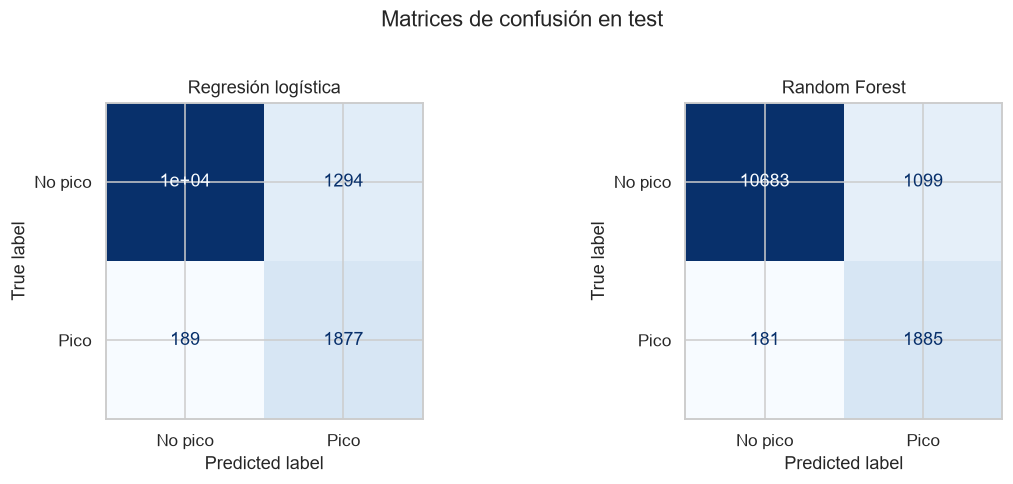

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, (nombre, modelo) in zip(axes, clasificadores.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, pico_test, display_labels=["No pico", "Pico"], cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(nombre)
fig.suptitle("Matrices de confusión en test", y=1.02)
guardar("matrices_confusion")

In [27]:
mejor_clf = tabla_clf["AUC-PR"].idxmax()
print(f"Reporte del mejor clasificador ({mejor_clf}):\n")
print(classification_report(pico_test, clasificadores[mejor_clf].predict(X_test), target_names=["No pico", "Pico"]))

Reporte del mejor clasificador (Random Forest):

              precision    recall  f1-score   support

     No pico       0.98      0.91      0.94     11782
        Pico       0.63      0.91      0.75      2066

    accuracy                           0.91     13848
   macro avg       0.81      0.91      0.85     13848
weighted avg       0.93      0.91      0.91     13848



Lectura:

- El Random Forest **anticipa el 91 % de las horas pico** (recall) y gana en todas las métricas a la regresión logística.
- De sus alertas, el 63 % son picos reales (precisión). Las falsas alarmas son el costo de priorizar el recall, que es lo que le conviene al operador.
- Que en test haya 14,9 % de horas pico contra 10 % en train es otra cara de la tendencia de crecimiento: con el mismo umbral, cada año hay más horas que lo superan.

## 13. Conclusiones

**Regresión: predecir los MWh de cada hora**

| Modelo | MAPE validación | MAPE test |
|---|---|---|
| Referencia ingenua (perfil promedio) | — | 7,6 % |
| Regresión lineal | 6,3 % | 6,0 % |
| Random Forest | 4,8 % | 4,2 % |
| **Gradient Boosting** | **4,5 %** | **4,0 %** |

- **Modelo elegido: Gradient Boosting**, por tener el menor error en validación cruzada. En el test lo confirma: se equivoca en promedio un **4,0 %**, contra 7,6 % de la referencia ingenua. Reduce el error casi a la mitad sin usar demanda pasada, solo calendario y temperatura.
- Los modelos de árboles le ganan a la regresión lineal porque capturan la interacción hora × estación (el pico de la tarde en verano y de la noche en invierno) sin construirla a mano.
- **Overfitting controlado:** la curva de validación muestra que más allá de cierta profundidad el error de validación no mejora mientras el de entrenamiento sigue bajando. La búsqueda de hiperparámetros con validación cruzada temporal eligió configuraciones regularizadas. El Gradient Boosting tiene la menor brecha entre train y test (3,4 % contra 4,0 %).

**Clasificación: anticipar horas pico**

- El Random Forest clasificador anticipa el **91 % de las horas pico** con una precisión del 63 % (AUC-PR 0,88), y supera a la regresión logística.

**Limitaciones**

- **Tendencia no modelada:** el modelo subestima cada vez más (0,7 % en 2025, 2,6 % en 2026) porque no conoce el crecimiento de la demanda. En la práctica habría que reentrenarlo periódicamente o sumar una variable de tendencia.
- **Temperatura observada como "pronóstico perfecto":** en la operación real se usaría el pronóstico del tiempo, que tiene error, así que el error del modelo sería algo mayor.
- **Una sola ciudad:** la temperatura de Buenos Aires no captura bien las olas de calor nacionales. Por eso el mayor error está en las tardes de verano.
